In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df=pd.read_csv("car_price_prediction.csv")

In [3]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   float64
 1   Brand         2250 non-null   object 
 2   Year          2250 non-null   float64
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   object 
 5   Transmission  2250 non-null   object 
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   object 
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 195.4+ KB


,Car ID,Year,Engine Size,Mileage,Price
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,1251.243556,2011.577778,3.485467,150236.178222,52506.874391
std,725.637358,6.980468,1.427690,88150.746556,27232.417079
min,1.000000,2000.000000,1.000000,15.000000,5011.270000
25%,627.250000,2005.000000,2.300000,71178.500000,28985.052500
50%,1249.500000,2012.000000,3.450000,149762.000000,53485.240000
75%,1875.250000,2018.000000,4.700000,226299.000000,75560.340000
max,2500.000000,2023.000000,6.000000,299967.000000,99982.590000


In [33]:
print(df.columns)

Index(['Brand', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model', 'Car_Age'],
      dtype='object')


In [27]:
df.isnull().sum()

Brand           0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
Car_Age         0
dtype: int64

In [36]:
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

# categorical columns
for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna(df[col].mode()[0])

# EDA

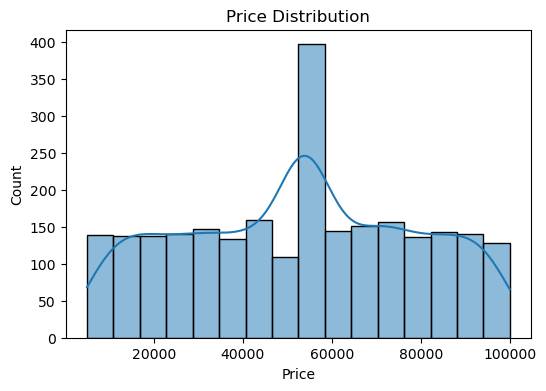

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

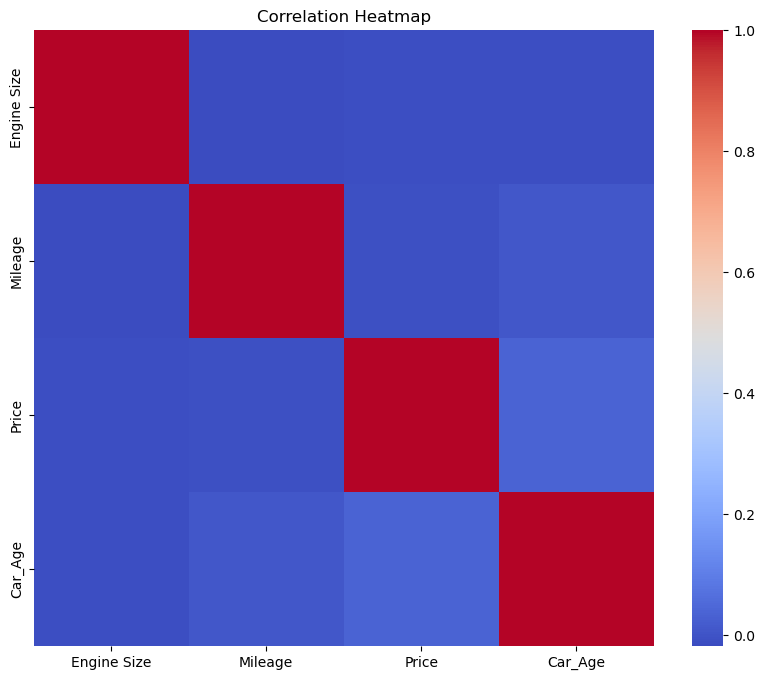

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [40]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [41]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough")

In [43]:
rf = RandomForestRegressor(random_state=42)

In [44]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

C:\Users\gyana\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [200, 400]},
             scoring='r2')

In [46]:
best_model = grid.best_estimator_

In [47]:
y_pred = best_model.predict(X_test)

In [48]:
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: -0.04086808668032993
Mean Squared Error: 385237314.26148206
